.+## Dependencies

Let’s start by installing the essential libraries we’ll need for fine-tuning! 🚀


In [83]:
!python --version

Python 3.10.20


In [84]:
import torch

In [85]:
torch.__version__

'2.5.1+cu121'

In [ ]:
!pip install transformers
!pip install datasets
!pip install bitsandbytes
!pip install peft
!pip install accelerate
!pip install trl
!pip install qwen-vl-utils[decord]==0.0.8

In [ ]:
# !pip install  -U -q git+https://github.com/huggingface/transformers.git git+https://github.com/huggingface/trl.git datasets bitsandbytes peft wandb accelerate
# Tested with transformers==4.47.0.dev0, trl==0.12.0.dev0, datasets==3.0.2, bitsandbytes==0.44.1, peft==0.13.2, qwen-vl-utils==0.0.8, wandb==0.18.5, accelerate==1.0.1

We’ll also need to install an earlier version of *PyTorch*, as the latest version has an issue that currently prevents this notebook from running correctly. You can learn more about the issue [here](https://github.com/pytorch/pytorch/issues/138340) and consider updating to the latest version once it’s resolved.

In [ ]:
# !pip install -q torch==2.4.1+cu121 torchvision==0.19.1+cu121 torchaudio==2.4.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

Log in to Hugging Face to upload your fine-tuned model! 🗝️

You’ll need to authenticate with your Hugging Face account to save and share your model directly from this notebook.


In [ ]:
import gc
import time
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoProcessor
from transformers import Qwen2_5_VLProcessor
from transformers import Qwen2_5_VLForConditionalGeneration
from transformers import BitsAndBytesConfig
from qwen_vl_utils import process_vision_info
from peft import LoraConfig, get_peft_model
from trl import SFTConfig
from trl import SFTTrainer

## Dataset

In this section, we’ll load the [SimulaMet-HOST/Kvasir-VQA](https://huggingface.co/datasets/SimulaMet-HOST/Kvasir-VQA) dataset. This dataset contains gastrointestinal images paired with related questions and answers, making it ideal for training on visual question answering tasks.




In [ ]:
# from huggingface_hub import login

# login()

In [ ]:
dataset_id = "SimulaMet-HOST/Kvasir-VQA"
# dataset = load_dataset(dataset_id, split=['raw_annotations[:1%]'])
dataset = load_dataset(dataset_id, split="raw", streaming=True)

For educational purposes, we’ll load only a small part of the dataset. However, in a real-world use case, you would typically load the entire set of samples.


In [ ]:
# data_small = [data for dataset]
dataset_small = list(dataset.take(1000))  # 增大取样规模，提供更充分的训练/测试数据

In [ ]:
dataset_train_small, dataset_test_small = dataset_small[:900], dataset_small[900:]

Let’s take a look at the structure of the dataset. It includes an image, a query, a label (which is the answer), and a fourth feature that we’ll be discarding.


In [ ]:
dataset_train_small[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>,
 'source': 'Ulcerative Colitis',
 'question': 'Are there any abnormalities in the image? Check all that are present.',
 'answer': 'ulcerative colitis',
 'img_id': 'cla820gl0s3nv071u4fgd7xgq'}

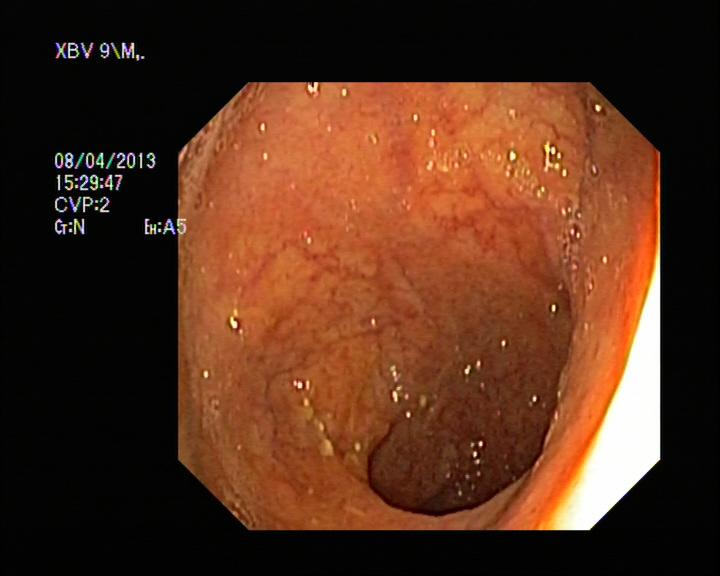

In [ ]:
dataset_train_small[0]['image']

We’ll format the dataset into a chatbot structure for interaction. Each interaction will consist of a system message, followed by the image and the user's query, and finally, the answer to the query.

💡For more usage tips specific to this model, check out the [Model Card](https://huggingface.co/Qwen/Qwen2-VL-7B-Instruct#more-usage-tips).

In [ ]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from medical images.
Your task is to analyze the provided gastrointestinal medical image and respond to queries with concise answers, usually a single word, number, or short phrase.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""
# The question types include Yes/No Questions, Single-Choice Questions, Multiple-Choice Questions, Color-Related Questions, Location-Related Questions, and Numerical Count Questions.

In [ ]:
def format_data(sample):
    return [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": system_message
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": sample["image"],
                },
                {
                    "type": "text",
                    "text": sample['question'],
                }
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": sample["answer"]
                }
            ],
        },
    ]

In [ ]:
# train_dataset, eval_dataset, test_dataset

Now, let’s format the data using the chatbot structure. This will allow us to set up the interactions appropriately for our model.


In [ ]:
train_dataset = [format_data(sample) for sample in dataset_train_small]
# eval_dataset = [format_data(sample) for sample in eval_dataset]
test_dataset = [format_data(sample) for sample in dataset_test_small]

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
train_dataset[0]

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are a Vision Language Model specialized in interpreting visual data from medical images.\nYour task is to analyze the provided gastrointestinal medical image and respond to queries with concise answers, usually a single word, number, or short phrase.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>},
   {'type': 'text',
    'text': 'Are there any abnormalities in the image? Check all that are present.'}]},
 {'role': 'assistant',
  'content': [{'type': 'text', 'text': 'ulcerative colitis'}]}]

In [ ]:
train_dataset[0][1] # 1 is user input

{'role': 'user',
 'content': [{'type': 'image',
   'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>},
  {'type': 'text',
   'text': 'Are there any abnormalities in the image? Check all that are present.'}]}

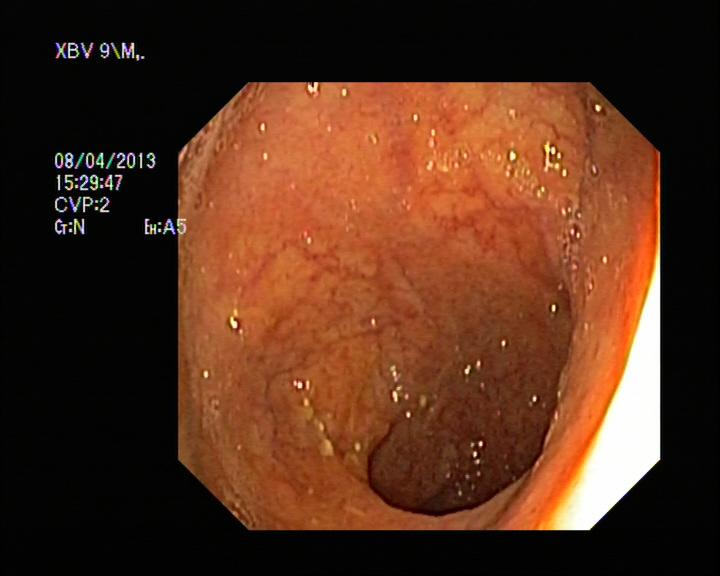

In [ ]:
train_dataset[0][1]['content'][0]['image'] # content 0 is image dict, content 1 is text dict

In [ ]:
train_dataset[0][2]['content'][0]['text'] # content 0 is text dict

'ulcerative colitis'

In [ ]:
# model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

Next, we’ll load the model and the tokenizer to prepare for inference.

In [ ]:
# model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     model_id,
#     device_map="auto",
#     torch_dtype=torch.bfloat16,
# )

In [ ]:
# min_pixels = 256*28*28
# max_pixels = 1280*28*28
# # processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct", min_pixels=min_pixels, max_pixels=max_pixels)
# processor = Qwen2_5_VLProcessor.from_pretrained(model_id)

To evaluate the model's performance, we’ll use a sample from the dataset. First, let’s take a look at the internal structure of this sample.


We’ll use the sample without the system message to assess the VLM's raw understanding. Here’s the input we will use:

Now, let’s take a look at the chart corresponding to the sample. Can you answer the query based on the visual information?


Let’s create a method that takes the model, processor, and sample as inputs to generate the model's answer. This will allow us to streamline the inference process and easily evaluate the VLM's performance.


In [ ]:
# Example of how to call the method with sample:
# output = generate_text_from_sample(model, processor, process_vision_info, train_dataset[0])
# output

While the model successfully retrieves the correct visual information, it struggles to answer the question accurately. This indicates that fine-tuning might be the key to enhancing its performance. Let’s proceed with the fine-tuning process!


## Experiment


### Load the Quantized Model for Training ⚙️




Next, we’ll load the quantized model using [bitsandbytes](https://huggingface.co/docs/bitsandbytes/main/en/index). If you want to learn more about quantization, check out [this blog post](https://huggingface.co/blog/merve/quantization) or [this one](https://www.maartengrootendorst.com/blog/quantization/).

In [ ]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

In [ ]:
# BitsAndBytesConfig int-4 config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
# Load model and tokenizer
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config
)
# load image processor
processor = Qwen2_5_VLProcessor.from_pretrained(model_id)

Fetching 2 files: 100%|██████████| 2/2 [00:00<?, ?it/s]


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

### Set Up QLoRA and SFTConfig 🚀

Next, we will configure [QLoRA](https://github.com/artidoro/qlora) for our training setup. QLoRA enables efficient fine-tuning of large language models while significantly reducing the memory footprint compared to traditional methods. Unlike standard LoRA, which reduces memory usage by applying a low-rank approximation, QLoRA takes it a step further by quantizing the weights of the LoRA adapters. This leads to even lower memory requirements and improved training efficiency, making it an excellent choice for optimizing our model's performance without sacrificing quality.




In [ ]:
# Configure LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM",
)
# Apply PEFT model adaptation
peft_model = get_peft_model(model, peft_config)
# Print trainable parameters
peft_model.print_trainable_parameters()

trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


We will use Supervised Fine-Tuning (SFT) to refine our model’s performance on the task at hand. To do this, we'll define the training arguments using the [SFTConfig](https://huggingface.co/docs/trl/sft_trainer) class from the [TRL library](https://huggingface.co/docs/trl/index). SFT allows us to provide labeled data, helping the model learn to generate more accurate responses based on the input it receives. This approach ensures that the model is tailored to our specific use case, leading to better performance in understanding and responding to visual queries.






In [ ]:
# Configure training arguments
training_args = SFTConfig(
    # Directory to save the model
    output_dir="qwen2.5-3b-instruct-trl-sft-kvasir-vqa",
    num_train_epochs=2,  # Number of training epochs
    per_device_train_batch_size=1,  # Batch size for training
    gradient_accumulation_steps=8,  # Steps to accumulate gradients
    # Enable gradient checkpointing for memory efficiency
    gradient_checkpointing=True,
    # Gradient checkpointing settings
    gradient_checkpointing_kwargs={"use_reentrant": False},
    # Optimizer and scheduler settings
    optim="adamw_torch_fused",  # Optimizer type
    learning_rate=2e-4,  # Learning rate for training
    lr_scheduler_type="constant",  # Type of learning rate scheduler
    # Logging and evaluation
    logging_steps=5,  # Steps interval for logging
    # Mixed precision and gradient settings
    bf16=True,  # Use bfloat16 precision
    # tf32=True,  # Use TensorFloat-32 precision
    max_grad_norm=0.3,  # Maximum norm for gradient clipping
    warmup_ratio=0.03,  # Ratio of total steps for warmup
    report_to="none",  # Reporting tool for tracking metrics
    # Dataset configuration
    dataset_text_field="",  # Text field in dataset
    dataset_kwargs={"skip_prepare_dataset": True},  # Additional dataset options
    #max_seq_length=1024  # Maximum sequence length for input
)
training_args.remove_unused_columns = False  # Keep unused columns in dataset

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### Training the Model 🏃

We need a collator function to properly retrieve and batch the data during the training procedure. This function will handle the formatting of our dataset inputs, ensuring they are correctly structured for the model. Let's define the collator function below.

👉 Check out the TRL official example [scripts]( https://github.com/huggingface/trl/blob/main/examples/scripts/sft_vlm.py#L87) for more details.


In [ ]:
# Create a data collator to encode text and image pairs
def collate_fn(examples):
    # Get the texts and images, and apply the chat template
    texts = [processor.apply_chat_template(example, tokenize=False) for example in examples]  # Prepare texts for processing
    image_inputs = [process_vision_info(example)[0] for example in examples]  # Process the images to extract inputs
    # Tokenize the texts and process the images
    batch = processor(text=texts, images=image_inputs, return_tensors="pt", padding=True)  # Encode texts and images into tensors
    # The labels are the input_ids, and we mask the padding tokens in the loss computation
    labels = batch["input_ids"].clone()  # Clone input IDs for labels
    labels[labels == processor.tokenizer.pad_token_id] = -100  # Mask padding tokens in labels
    # Ignore the image token index in the loss computation (model specific)
    if isinstance(processor, Qwen2_5_VLProcessor):  # Check if the processor is QwenVLProcessor
        image_tokens = [151652, 151653, 151655]  # Specific image token IDs for QwenVLProcessor
    else:
        image_tokens = [processor.tokenizer.convert_tokens_to_ids(processor.image_token)]  # Convert image token to ID
    # Mask image token IDs in the labels
    for image_token_id in image_tokens:
        labels[labels == image_token_id] = -100  # Mask image token IDs in labels
    batch["labels"] = labels  # Add labels to the batch
    return batch  # Return the prepared batch

Now, we will define the [SFTTrainer](https://huggingface.co/docs/trl/sft_trainer), which is a wrapper around the [transformers.Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) class and inherits its attributes and methods. This class simplifies the fine-tuning process by properly initializing the [PeftModel](https://huggingface.co/docs/peft/v0.6.0/package_reference/peft_model) when a [PeftConfig](https://huggingface.co/docs/peft/v0.6.0/en/package_reference/config#peft.PeftConfig) object is provided. By using `SFTTrainer`, we can efficiently manage the training workflow and ensure a smooth fine-tuning experience for our Vision Language Model.



In [ ]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    peft_config=peft_config
)

c:\Users\21799\anaconda3\envs\qwen_train\lib\site-packages\peft\mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
c:\Users\21799\anaconda3\envs\qwen_train\lib\site-packages\peft\tuners\tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Time to Train the Model! 🎉

In [ ]:
torch.cuda.reset_peak_memory_stats()
train_start_time = time.time()

trainer.train()

train_elapsed = time.time() - train_start_time
train_peak_vram = torch.cuda.max_memory_allocated() / 1024**3
print(f"Training Time: {train_elapsed/60:.2f} min")
print(f"Peak VRAM during training: {train_peak_vram:.2f} GB")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss


KeyboardInterrupt: 

We will utilize the previous sample from the dataset that the model initially struggled to answer correctly.

save the model

In [ ]:
trainer.save_model(training_args.output_dir)

# Test

**Remove Model and Clean GPU**

Before we proceed with training the model in the next section, let's clear the current variables and clean the GPU to free up resources.



In [ ]:
print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU allocated memory: 2.42 GB
GPU reserved memory: 7.23 GB


In [ ]:
def clear_memory():
    # Delete variables if they exist in the current global scope
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    if "trainer" in globals():
        del globals()["trainer"]
    if "peft_model" in globals():
        del globals()["peft_model"]
    if "bnb_config" in globals():
        del globals()["bnb_config"]
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

In [ ]:
clear_memory()

GPU allocated memory: 2.42 GB
GPU reserved memory: 2.55 GB


load the trained model for inference

In [ ]:
from transformers import BitsAndBytesConfig

# 复用训练时的 int-4 量化配置，减少显存占用，避免设备拆分导致 LoRA 层设备不一致
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,
)

processor = Qwen2_5_VLProcessor.from_pretrained(model_id)

Loading weights: 100%|██████████| 824/824 [00:12<00:00, 65.73it/s] 


In [ ]:
adapter_path = training_args.output_dir
model.load_adapter(adapter_path)

Loading weights: 100%|██████████| 144/144 [00:00<00:00, 3009.82it/s]


LoadStateDictInfo(missing_keys=set(), unexpected_keys=set(), mismatched_keys=set(), error_msgs=[], conversion_errors={})

In [ ]:
test_dataset[0][:2]

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are a Vision Language Model specialized in interpreting visual data from medical images.\nYour task is to analyze the provided gastrointestinal medical image and respond to queries with concise answers, usually a single word, number, or short phrase.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=720x576>},
   {'type': 'text', 'text': 'Where in the image is the abnormality?'}]}]

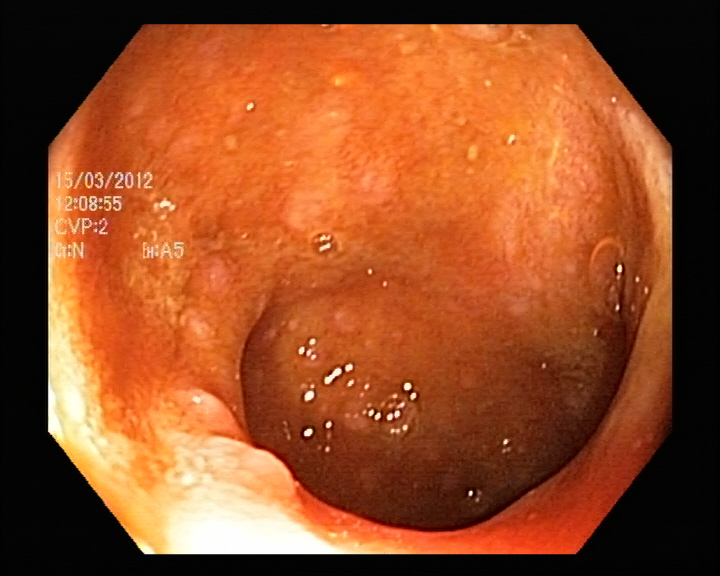

In [ ]:
test_dataset[0][1]['content'][0]['image']

ground truth output

In [ ]:
test_dataset[0][2]['content'][0]['text'] # content 0 is text dict

'center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right'

In [ ]:
def generate_text_from_sample(model, processor, process_vision_info, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    text_input = processor.apply_chat_template(
        sample[0:2],  # Use the sample with the system message
        tokenize=False,
        add_generation_prompt=True
    )
    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample)
    # Prepare the inputs for the model
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)  # Move inputs to the specified device
    # 贪婪解码：每步都取概率最高的 token，保证同一输入的结果可复现
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens, do_sample=False)
    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    return output_text[0]  # Return the first decoded output text

prediction

In [ ]:
output = generate_text_from_sample(model, processor, process_vision_info, test_dataset[0])
output



'center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right'

评估方式

In [ ]:
%pip install -q rouge-score pycocoevalcap sacrebleu nltk

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


Note: you may need to restart the kernel to use updated packages.


True

In [ ]:
def evaluate_predictions(model, processor, process_vision_info, dataset, max_samples=None):
    """在测试集上逐条生成预测答案，收集参考答案与预测答案，供后续计算 BLEU/ROUGE/METEOR/CIDEr 使用"""
    samples = dataset if max_samples is None else dataset[:max_samples]
    references, hypotheses = [], []
    for sample in samples:
        ground_truth = sample[2]['content'][0]['text']
        prediction = generate_text_from_sample(model, processor, process_vision_info, sample)
        references.append(ground_truth)
        hypotheses.append(prediction)
    return references, hypotheses

references, hypotheses = evaluate_predictions(model, processor, process_vision_info, test_dataset)
for gt, pred in zip(references, hypotheses):
    print(f"GT: {gt!r}  |  Pred: {pred!r}")


GT: 'center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right'  |  Pred: 'center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right'
GT: 'pink; red; white'  |  Pred: 'pink; red; yellow; white'
GT: '0'  |  Pred: '0'
GT: 'none'  |  Pred: 'none'
GT: 'none'  |  Pred: 'none'
GT: 'ulcerative colitis'  |  Pred: 'ulcerative colitis'
GT: 'yes'  |  Pred: 'yes'
GT: 'yes'  |  Pred: 'yes'
GT: '0'  |  Pred: '0'
GT: 'none'  |  Pred: 'none'
GT: 'yes'  |  Pred: 'yes'
GT: 'not relevant'  |  Pred: 'not relevant'
GT: 'center; center-left; center-right; lower-center; lower-right; upper-center; upper-left; upper-right'  |  Pred: 'center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right'
GT: 'none'  |  Pred: 'none'
GT: '1'  |  Pred: '1'
GT: 'none'  |  Pred: 'none'
GT: 'none'  |  Pred: 'none'
GT: 'colonoscopy'  |  Pred: 'colonoscopy'
GT: 'colonosco

In [ ]:
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from pycocoevalcap.cider.cider import Cider

smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

bleu_scores, meteor_scores = [], []
rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
gts, res = {}, {}  # CIDEr 所需格式：{id: [参考答案]} / {id: [预测答案]}

for idx, (ref, hyp) in enumerate(zip(references, hypotheses)):
    ref_tokens, hyp_tokens = ref.lower().split(), hyp.lower().split()

    bleu_scores.append(sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoothie))
    meteor_scores.append(meteor_score([ref_tokens], hyp_tokens))

    rouge_result = rouge.score(ref, hyp)
    rouge1_scores.append(rouge_result['rouge1'].fmeasure)
    rouge2_scores.append(rouge_result['rouge2'].fmeasure)
    rougeL_scores.append(rouge_result['rougeL'].fmeasure)

    gts[idx] = [ref]
    res[idx] = [hyp]

cider_score, _ = Cider().compute_score(gts, res)

results = pd.DataFrame({
    "指标": ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR", "CIDEr"],
    "得分": [
        sum(bleu_scores) / len(bleu_scores),
        sum(rouge1_scores) / len(rouge1_scores),
        sum(rouge2_scores) / len(rouge2_scores),
        sum(rougeL_scores) / len(rougeL_scores),
        sum(meteor_scores) / len(meteor_scores),
        cider_score,
    ],
})
results


,指标,得分
0,BLEU,0.831124
1,ROUGE-1,0.967226
2,ROUGE-2,0.223333
3,ROUGE-L,0.967226
4,METEOR,0.583614
5,CIDEr,3.204810


导出更多测试样本（图片 + 参考答案），供自测使用

In [ ]:
from pathlib import Path
import pandas as pd

# 从测试集里再挑几个样本（跳过已经用过的 test_dataset[0]），保存图片 + 记录参考答案，方便自己手动测试
NUM_SAMPLES = 5
START_INDEX = 1  # test_dataset[0] 前面已经用过了

export_dir = Path("reference_samples")
export_dir.mkdir(exist_ok=True)

records = []
for i in range(START_INDEX, START_INDEX + NUM_SAMPLES):
    sample = test_dataset[i]
    image = sample[1]['content'][0]['image']       # user 消息里的图像
    question = sample[1]['content'][1]['text']      # user 消息里的问题
    reference_answer = sample[2]['content'][0]['text']  # assistant 消息里的参考答案

    image_filename = f"sample_{i}.jpg"
    image.convert("RGB").save(export_dir / image_filename)

    records.append({
        "index": i,
        "image_filename": image_filename,
        "question": question,
        "reference_answer": reference_answer,
    })

df = pd.DataFrame(records)
df.to_csv(export_dir / "reference_answers.csv", index=False, encoding="utf-8-sig")
print(f"已导出 {len(records)} 个样本到 {export_dir.resolve()}")
df


已导出 5 个样本到 C:\Users\21799\Desktop\msc imh\xinqifan code\reference_samples


,index,image_filename,question,reference_answer
0,1,sample_1.jpg,What color is the abnormality? If more than on...,pink; red; white
1,2,sample_2.jpg,How many polyps are in the image?,0
2,3,sample_3.jpg,Are there any instruments in the image? Check ...,none
3,4,sample_4.jpg,What type of polyp is present?,none
4,5,sample_5.jpg,Are there any abnormalities in the image? Chec...,ulcerative colitis


INFO:     127.0.0.1:57457 - "POST /api/vqa HTTP/1.1" 200 OK
INFO:     127.0.0.1:57457 - "GET /api/history HTTP/1.1" 200 OK


## 部署：FastAPI 推理服务

以下代码来自 `backweb/main.py`，将上面微调好的模型封装为一个 FastAPI 服务，对外提供 `/api/vqa`（视觉问答）、`/api/history`（历史记录查询/删除）等接口，方便与前端页面联调。

这里直接复用前面 cell 中已经加载好的 `model`、`processor`、`system_message`、`training_args` 等变量，无需重复加载模型。


In [ ]:
import io
import sqlite3
import uuid
from datetime import datetime
from pathlib import Path
from contextlib import asynccontextmanager

from fastapi import FastAPI, File, UploadFile, Form, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image

# 数据库 & 图片存储路径（放在 notebook 同级的 backweb/ 目录下，与后端脚本共用）
_HERE = Path.cwd() / "backweb"
_HERE.mkdir(exist_ok=True)
DB_PATH = str(_HERE / "vqa_history.db")
UPLOADS_DIR = _HERE / "uploads"
UPLOADS_DIR.mkdir(exist_ok=True)

# 与训练时相同的系统提示词（复用前面定义的 system_message）
SYSTEM_MESSAGE = system_message

# 微调后的 adapter 路径（复用训练时的 output_dir）
SERVE_ADAPTER_PATH = training_args.output_dir


In [ ]:
def init_db() -> None:
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS vqa_history (
            id             INTEGER PRIMARY KEY AUTOINCREMENT,
            created_at     TEXT    NOT NULL,
            image_filename TEXT    NOT NULL,
            image_path     TEXT    NOT NULL,
            question       TEXT    NOT NULL,
            answer         TEXT    NOT NULL
        )
    """)
    conn.commit()
    conn.close()


def db_save(image_filename: str, image_path: str, question: str, answer: str) -> int:
    conn = sqlite3.connect(DB_PATH)
    cur = conn.execute(
        "INSERT INTO vqa_history "
        "(created_at, image_filename, image_path, question, answer) VALUES (?,?,?,?,?)",
        (
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            image_filename,
            image_path,
            question,
            answer,
        ),
    )
    record_id = cur.lastrowid
    conn.commit()
    conn.close()
    return record_id


def db_list(limit: int = 50) -> list:
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    rows = conn.execute(
        "SELECT * FROM vqa_history ORDER BY id DESC LIMIT ?", (limit,)
    ).fetchall()
    conn.close()
    return [dict(r) for r in rows]


def db_delete(record_id: int) -> None:
    conn = sqlite3.connect(DB_PATH)
    conn.execute("DELETE FROM vqa_history WHERE id = ?", (record_id,))
    conn.commit()
    conn.close()


In [ ]:
@asynccontextmanager
async def lifespan(app: FastAPI):
    """应用启动时初始化数据库（模型已在前面的 cell 中加载完成，此处直接复用）。"""
    init_db()
    print("数据库已初始化，服务已就绪（复用已加载的 model / processor）。")
    yield


app = FastAPI(lifespan=lifespan)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


def generate_answer(image: Image.Image, question: str, max_new_tokens: int = 512) -> str:
    """使用微调后的 Qwen2.5-VL 模型对图像进行视觉问答推理（复用 model / processor）。"""
    sample = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_MESSAGE}],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        },
    ]

    text_input = processor.apply_chat_template(
        sample,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, _ = process_vision_info(sample)

    device = next(model.parameters()).device
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)

    # 贪婪解码：每步都取概率最高的 token，保证同一输入的结果可复现
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    return processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

In [ ]:
@app.get("/api/hello")
def say_hello():
    return {"message": "Hello from backend!"}


@app.get("/")
def read_root():
    return {"Hello": "World"}


@app.get("/ite/{item_i}/{q}")
def read_ite(item_i: int, q: str):
    return {"item_id": item_i, "p": q}


@app.post("/api/vqa")
async def visual_question_answering(
    image: UploadFile = File(..., description="胃肠道医学图像文件"),
    question: str = Form(..., description="关于图像的问题"),
):
    contents = await image.read()
    try:
        pil_image = Image.open(io.BytesIO(contents)).convert("RGB")
    except Exception:
        raise HTTPException(status_code=400, detail="无效的图像文件")

    original_name = image.filename or "upload.jpg"
    safe_name = f"{uuid.uuid4().hex[:8]}_{original_name}"
    save_path = UPLOADS_DIR / safe_name
    save_path.write_bytes(contents)

    answer = generate_answer(pil_image, question)
    record_id = db_save(original_name, str(save_path), question, answer)
    return {"answer": answer, "id": record_id}


@app.get("/api/history")
def get_history(limit: int = 50):
    return {"history": db_list(limit)}


@app.delete("/api/history/{record_id}")
def delete_history(record_id: int):
    db_delete(record_id)
    return {"ok": True}


### 启动服务

运行下面的 cell 会启动 FastAPI 服务并一直占用当前内核（阻塞），如需停止请中断（Interrupt）该 cell。

如果在 Jupyter/Notebook 环境中运行 `uvicorn.run(...)` 报 "asyncio.run() cannot be called from a running event loop" 之类的错误，先执行 `pip install nest_asyncio` 并在下面 cell 顶部加上：
```python
import nest_asyncio
nest_asyncio.apply()
```


In [ ]:
if __name__ == "__main__":
    import threading
    import uvicorn

    # Jupyter 内核所在线程已有运行中的事件循环，uvicorn.run() 无法在其中直接调用
    # 因此在独立线程中启动 uvicorn，该线程没有正在运行的事件循环
    def _run_server():
        uvicorn.run(app, host="0.0.0.0", port=8080)

    server_thread = threading.Thread(target=_run_server, daemon=True)
    server_thread.start()


INFO:     Started server process [35204]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8080 (Press CTRL+C to quit)


数据库已初始化，服务已就绪（复用已加载的 model / processor）。
INFO:     127.0.0.1:60646 - "GET /api/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:52721 - "GET /api/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "GET /api/history HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "OPTIONS /api/history/6 HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "DELETE /api/history/6 HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "OPTIONS /api/history/5 HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "DELETE /api/history/5 HTTP/1.1" 200 OK
INFO:     127.0.0.1:24238 - "OPTIONS /api/history/4 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "DELETE /api/history/4 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "OPTIONS /api/history/3 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "DELETE /api/history/3 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "OPTIONS /api/history/2 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "DELETE /api/history/2 HTTP/1.1" 200 OK
INFO:     127.0.0.1:59739 - "OPTIONS /api/history/1 HTTP/1.1" 200 OK
INFO:     127.0.